In [12]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
words = open('../names.txt', 'r').read().splitlines()

32033


In [ ]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

# stoi maps character to integers
# itos maps integers to characters

27


In [32]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
    

# What happens here is that we have a window of length block_size. We move the window across the window across
# the name to get all the possible contexts of length block_size. For each of these, we assign the label as the 
# next character. 

import random
random.seed(42)
random.shuffle(words)

# We choose n1 so that its 80% of the words
n1 = int(0.8*len(words))
# n2 is chosen to be 90% of the words
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [54]:
# MLP revisited

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / 10**(0.5)
b1 = torch.randn(n_hidden, generator=g) * 0
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [50]:
# optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # Concatenate the layers
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    

      0/ 200000: 3.6013
  10000/ 200000: 1.7301
  20000/ 200000: 1.9046
  30000/ 200000: 2.3953
  40000/ 200000: 2.4503
  50000/ 200000: 1.8569
  60000/ 200000: 2.4715
  70000/ 200000: 2.0948
  80000/ 200000: 1.7409
  90000/ 200000: 2.2320
 100000/ 200000: 2.2185
 110000/ 200000: 2.0645
 120000/ 200000: 1.8690
 130000/ 200000: 1.7448
 140000/ 200000: 2.1494
 150000/ 200000: 2.2424
 160000/ 200000: 1.8046
 170000/ 200000: 2.0837
 180000/ 200000: 2.6580
 190000/ 200000: 1.7397


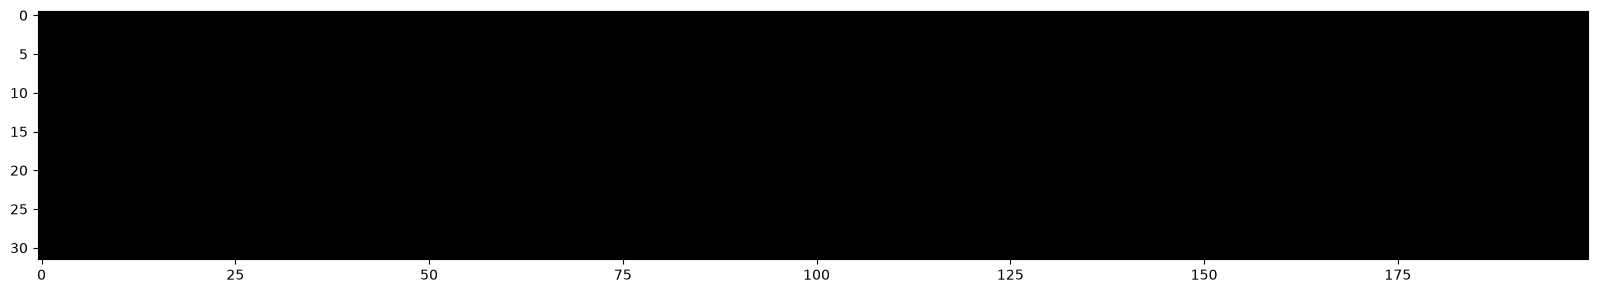

In [46]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

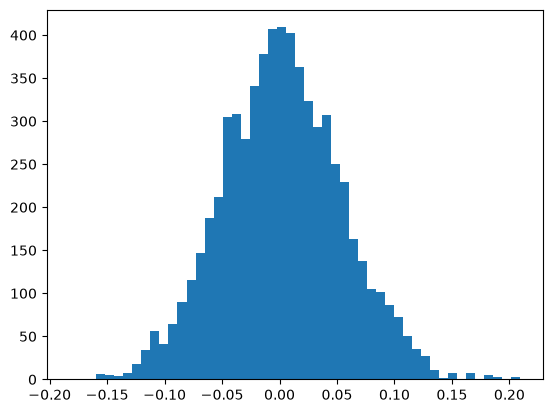

In [47]:
plt.hist(h.view(-1).tolist(), 50);

ValueError: x and y must have same first dimension, but have shapes (200000,) and (1,)

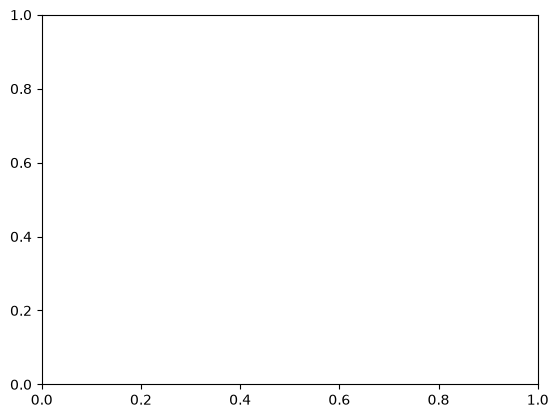

In [48]:
plt.plot(range(200000), lossi)
plt.show()

In [52]:
# Evaluate on validation and test data

@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0350515842437744
val 2.1203789710998535


In [38]:
# Sample from the model
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)

        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print name

wiler.
keyler.
alizalizton.
fadalexta.
kheidi.
jaqu.
aimo.
poepe.
naf.
xar.
srickoralys.
kor.
iti.
cece.
kaxten.
adsia.
yhry.
lloriah.
saidenoruavlar.
ahra.


In [ ]:
# Make code more modular
class Linear:

    # Initialize weights and bias from a Gaussian
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__ (self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        

    